In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import dill

In [ ]:
#Due to github size limit, I have uploaded a zip folder with the data and the session file
#to google drive:  https://drive.google.com/file/d/1q4ikWeEgK-8oK1Zk_KH3WweY0EfTV0go/view?usp=sharing


In [2]:
br_21 = xr.open_dataset("data/BR-Npw/BR-Npw-wetlsp-2021.nc")
br_22 = xr.open_dataset("data/BR-Npw/BR-Npw-wetlsp-2022.nc")
br_23 = xr.open_dataset("data/BR-Npw/BR-Npw-wetlsp-2023.nc")
br_24 = xr.open_dataset("data/BR-Npw/BR-Npw-wetlsp-2024.nc")

In [3]:
de_21 = xr.open_dataset("data/DE-Hte/DE-Hte-wetlsp-2021.nc")
de_22 = xr.open_dataset("data/DE-Hte/DE-Hte-wetlsp-2022.nc")
de_23 = xr.open_dataset("data/DE-Hte/DE-Hte-wetlsp-2023.nc")
de_24 = xr.open_dataset("data/DE-Hte/DE-Hte-wetlsp-2024.nc")

In [4]:
usm_21 = xr.open_dataset("data/US-Myb/US-Myb-wetlsp-2021.nc")
usm_22 = xr.open_dataset("data/US-Myb/US-Myb-wetlsp-2022.nc")
usm_23 = xr.open_dataset("data/US-Myb/US-Myb-wetlsp-2023.nc")
usm_24 = xr.open_dataset("data/US-Myb/US-Myb-wetlsp-2024.nc")

In [5]:
uso_21 = xr.open_dataset("data/US-ORv/US-ORv-wetlsp-2021.nc")
uso_22 = xr.open_dataset("data/US-ORv/US-ORv-wetlsp-2022.nc")
uso_23 = xr.open_dataset("data/US-ORv/US-ORv-wetlsp-2023.nc")
uso_24 = xr.open_dataset("data/US-ORv/US-ORv-wetlsp-2024.nc")

In [6]:
bw_21 = xr.open_dataset("data/BW-Gum/BW-Gum-wetlsp-2021.nc")
bw_22 = xr.open_dataset("data/BW-Gum/BW-Gum-wetlsp-2022.nc")
bw_23 = xr.open_dataset("data/BW-Gum/BW-Gum-wetlsp-2023.nc")
bw_24 = xr.open_dataset("data/BW-Gum/BW-Gum-wetlsp-2024.nc")

In [7]:
nz_21 = xr.open_dataset("data/NZ-Kop/NZ-Kop-wetlsp-2021.nc")
nz_22 = xr.open_dataset("data/NZ-Kop/NZ-Kop-wetlsp-2022.nc")
nz_23 = xr.open_dataset("data/NZ-Kop/NZ-Kop-wetlsp-2023.nc")
nz_24 = xr.open_dataset("data/NZ-Kop/NZ-Kop-wetlsp-2024.nc")

In [ ]:
#Only run this if you want to load the previous session, otherwise comment it out. 
#This will load all the variables, functions and data from the previous session so you can continue working without having to re-run the entire analysis.

dill.load_session("phenology_classification_session.pkl")

In [8]:
# =============================================================================
# SECTION 1: CONFIGURATION
# =============================================================================

# --- Phenometric features to use in classification ---
# Cycle-1 variables: available for ALL pixels where QA <= 3
# NOTE (Idea 1 - onset alignment): OGI is kept in RAW_CYCLE1_VARS for reference
# and for use as the alignment anchor, but it is EXCLUDED from the final
# classification feature list (CYCLE1_VARS_FOR_CLUSTERING) once every timing
# variable has been re-expressed as "days since OGI" (it becomes a constant 0
# for every pixel after shifting, so it carries zero variance).
RAW_CYCLE1_VARS = [
    "NumCycles",   # Number of seasonal cycles detected
    "OGI",         # Onset of greenness increase (ANCHOR for shifting, not a cluster feature)
    "50PCGI",      # Date of 50% amplitude on rising limb
    "OGMx",        # Date of maximum greenness
    "Peak",        # Peak date
    "OGD",         # Onset of greenness decrease
    "50PCGD",      # Date of 50% amplitude on falling limb
    "OGMn",        # Date of minimum greenness
    "EVImax",       # Maximum EVI value
    "EVIamp",       # EVI amplitude (max - base)
    "EVIarea",      # Integrated EVI area (season-long greenness)
]

# Cycle-1 timing variables that get shifted relative to OGI (days-since-onset)
CYCLE1_TIMING_VARS = ["50PCGI", "OGMx", "Peak", "OGD", "50PCGD", "OGMn"]
# Cycle-1 non-timing variables, left untouched
CYCLE1_NONTIMING_VARS = ["NumCycles", "EVImax", "EVIamp", "EVIarea"]

# Cycle-2 variables: only meaningful where NumCycles >= 2 AND QA_2 <= 3
# For pixels without a second cycle, these are zero-filled (not dropped, not imputed with median)
CYCLE2_VARS = [
    "OGI_2", "50PCGI_2", "OGMx_2", "Peak_2",
    "OGD_2", "50PCGD_2", "OGMn_2",
    "EVImax_2", "EVIamp_2", "EVIarea_2"
]

# Cycle-2 timing variables that get shifted relative to CYCLE-1 OGI (preserves
# the true gap between cycle 1 and cycle 2 for bimodal pixels)
CYCLE2_TIMING_VARS = ["OGI_2", "50PCGI_2", "OGMx_2", "Peak_2", "OGD_2", "50PCGD_2", "OGMn_2"]
CYCLE2_NONTIMING_VARS = ["EVImax_2", "EVIamp_2", "EVIarea_2"]

DOY_PERIOD = 365  # used for wrap-around (%) when shifting timing variables by OGI

# Final feature list actually used for clustering (OGI dropped - see note above)
CYCLE1_VARS = ["NumCycles"] + CYCLE1_TIMING_VARS + ["EVImax", "EVIamp", "EVIarea"]

In [9]:
# Quality flag thresholds (QA values 1-4; 4 = lowest confidence)
QA_THRESHOLD = 3    # Keep QA <= 3 for cycle-1; pixels with QA=4 are excluded entirely
QA2_THRESHOLD = 3   # Keep QA_2 <= 3 for cycle-2; pixels failing this get has_cycle2=0

# K-Means parameters
K_RANGE = range(2, 10)      # Range of k values to test for elbow/silhouette
K_FINAL = 6                 # Starting guess; update after reviewing elbow plot
KMEANS_N_INIT = 20          # Number of random restarts (higher = more stable result)
RANDOM_STATE = 42           # For reproducibility

In [10]:
# =============================================================================
# SECTION 2: FEATURE EXTRACTION  (Idea 1: onset-relative "days since OGI")
# =============================================================================
# All timing anchors (cycle-1 and cycle-2) are re-expressed relative to the
# pixel's own cycle-1 OGI: shifted = (raw_day - OGI) % 365. This removes the
# location/seasonality signal (calendar date of onset) while preserving the
# SHAPE of the phenology curve (duration of green-up, time-to-peak, etc.).
#
# - Cycle-1 OGI itself becomes a constant 0 after shifting -> dropped from
#   the clustering feature set (see CYCLE1_VARS in Section 1).
# - Cycle-2 timing vars are shifted using the SAME cycle-1 OGI anchor (not
#   their own OGI_2), so the true temporal gap between cycle 1 and cycle 2
#   is preserved for bimodal pixels.
# - The %% 365 wrap keeps shifted values in [0, 365) even when a pixel's
#   season straddles the Dec/Jan boundary.

def extract_feature_matrix(ds, qa_threshold=QA_THRESHOLD, qa2_threshold=QA2_THRESHOLD):
    """
    Converts an xarray Dataset (one year of phenometrics) into a flat 2D feature matrix.

    Returns:
        X          : np.ndarray of shape (n_pixels, n_features) -- onset-shifted, clustering-ready
        X_raw_ogi  : np.ndarray of shape (n_pixels,) -- the raw (unshifted) OGI, kept for reference
                     / re-anchoring plots later (NOT part of the clustering feature matrix)
        mask_qa1   : 2D bool array (y, x) -- True where cycle-1 QA is acceptable
        shape      : tuple (y, x) -- spatial dimensions for reshaping labels back
        feat_names : list of feature column names (matches columns of X)
    """
    shape = ds[RAW_CYCLE1_VARS[0]].shape  # (y, x)

    # --- Build QA masks ---
    qa1 = ds["QA"].values          # Cycle-1 quality flag
    qa2 = ds["QA_2"].values        # Cycle-2 quality flag
    num_cycles = ds["NumCycles"].values  # Number of seasonal cycles

    # Cycle-1 mask: exclude pixels where QA is missing or below threshold
    mask_qa1 = (qa1 <= qa_threshold) & np.isfinite(qa1)

    # Cycle-2 presence: pixel must have >=2 cycles AND good QA_2
    has_cycle2 = (
        (num_cycles >= 2) &
        (qa2 <= qa2_threshold) &
        np.isfinite(qa2)
    ).astype(np.float32)  # 1.0 = has valid second cycle, 0.0 = does not

    # --- Onset anchor: raw cycle-1 OGI (day of year) ---
    ogi_raw = ds["OGI"].values.ravel().astype(np.float64)

    # --- Build cycle-1 feature columns ---
    arrays = []
    for v in CYCLE1_NONTIMING_VARS:
        arrays.append(ds[v].values.ravel())

    for v in CYCLE1_TIMING_VARS:
        raw = ds[v].values.ravel().astype(np.float64)
        shifted = (raw - ogi_raw) % DOY_PERIOD  # days since onset, wrap-safe
        arrays.append(shifted)

    # --- Add binary cycle-2 presence flag as its own feature ---
    arrays.append(has_cycle2.ravel())

    # --- Add cycle-2 feature columns (non-timing, unchanged) ---
    for v in CYCLE2_NONTIMING_VARS:
        arr = ds[v].values.copy()
        arr[~has_cycle2.astype(bool)] = 0.0
        arrays.append(arr.ravel())

    # --- Add cycle-2 timing columns, shifted by the SAME cycle-1 OGI anchor ---
    for v in CYCLE2_TIMING_VARS:
        raw = ds[v].values.ravel().astype(np.float64)
        shifted = (raw - ogi_raw) % DOY_PERIOD
        shifted[~has_cycle2.ravel().astype(bool)] = 0.0  # zero-fill where no second cycle
        arrays.append(shifted)

    X = np.stack(arrays, axis=1)  # Shape: (y*x, n_features)

    # Mark bad cycle-1 QA pixels as NaN so they are excluded from clustering
    X[~mask_qa1.ravel()] = np.nan

    feat_names = (
        CYCLE1_NONTIMING_VARS + CYCLE1_TIMING_VARS + ["has_cycle2"]
        + CYCLE2_NONTIMING_VARS + CYCLE2_TIMING_VARS
    )
    return X, ogi_raw, mask_qa1, shape, feat_names

In [11]:
# =============================================================================
# SECTION 3: POOL ALL YEARS INTO A SINGLE FEATURE MATRIX
# =============================================================================


site_datasets = {
    "br": {"2021": br_21, "2022": br_22, "2023": br_23, "2024": br_24},
    "bw": {"2021": bw_21, "2022": bw_22, "2023": bw_23, "2024": bw_24},
    "de": {"2021": de_21, "2022": de_22, "2023": de_23, "2024": de_24},
    "usm": {"2021": usm_21, "2022": usm_22, "2023": usm_23, "2024": usm_24},
    "uso": {"2021": uso_21, "2022": uso_22, "2023": uso_23, "2024": uso_24},
    "nz": {"2021": nz_21, "2022": nz_22, "2023": nz_23, "2024": nz_24},
}

all_X = []
all_ogi_raw = []  # raw (unshifted) cycle-1 OGI, aligned row-for-row with all_X -- kept for re-anchoring plots later
meta = []  # one entry per (site, year) combo
offset = 0

for site, years_dict in site_datasets.items():
    for year, ds in years_dict.items():
        X, ogi_raw, mask_qa1, shape, feat_names = extract_feature_matrix(ds)
        all_X.append(X)
        all_ogi_raw.append(ogi_raw)
        meta.append({
            "site": site, "year": year,
            "start": offset, "end": offset + X.shape[0],
            "shape": shape, "mask_qa1": mask_qa1,
        })
        offset += X.shape[0]

X_pooled = np.vstack(all_X)
ogi_raw_pooled = np.concatenate(all_ogi_raw)  # same row indexing as X_pooled
print(f"Pooled feature matrix shape: {X_pooled.shape}")
print(f"Sites: {list(site_datasets.keys())}")
print(f"Total (site, year) panels: {len(meta)}")

del all_X, all_ogi_raw  # free memory   

Pooled feature matrix shape: (30159908, 21)
Sites: ['br', 'bw', 'de', 'usm', 'uso', 'nz']
Total (site, year) panels: 24


In [12]:
# =============================================================================
# SECTION 4: EXCLUDE BAD-QA PIXELS (DO NOT IMPUTE)
# =============================================================================
# A pixel row is NaN if and only if its cycle-1 QA failed (QA=4 or missing).
# Cycle-2 NaNs are already zero-filled above -- so remaining NaNs are genuinely bad pixels.

# Identify rows where ALL features are finite (no NaN in any column)
valid_rows_mask = ~np.isnan(X_pooled).any(axis=1)
X_clean = X_pooled[valid_rows_mask]
ogi_raw_clean = ogi_raw_pooled[valid_rows_mask]  # kept aligned with X_clean for later re-anchoring
valid_indices = np.where(valid_rows_mask)[0]

n_total = X_pooled.shape[0]
n_valid = X_clean.shape[0]
n_dropped = n_total - n_valid
print(f"\nPixel summary:")
print(f"  Total pixels (all years):     {n_total:,}")
print(f"  Valid pixels retained:        {n_valid:,} ({100*n_valid/n_total:.1f}%)")
print(f"  Pixels dropped (bad QA1):     {n_dropped:,} ({100*n_dropped/n_total:.1f}%)")


Pixel summary:
  Total pixels (all years):     30,159,908
  Valid pixels retained:        14,052,268 (46.6%)
  Pixels dropped (bad QA1):     16,107,640 (53.4%)


In [13]:
# =============================================================================
# SECTION 5: STANDARDIZE FEATURES
# =============================================================================
# Phenometric variables span very different ranges:
# - Timing variables are now "days since OGI" (0-365, onset-relative instead of calendar day-of-year)
# - EVI values (EVImax, EVIamp, EVIarea) are scaled 0-1 or 0-10000
# - NumCycles is 0-6, has_cycle2 is 0-1
#
# Without standardization, large-range timing variables dominate the Euclidean
# distance metric used by K-Means. StandardScaler transforms each feature to
# mean=0, std=1 so every variable contributes equally.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)


Running elbow + silhouette diagnostics...
  k=2: inertia=147,268,954, silhouette=0.6100
  k=3: inertia=111,981,138, silhouette=0.3075
  k=4: inertia=98,717,254, silhouette=0.2954
  k=5: inertia=86,589,819, silhouette=0.2617
  k=6: inertia=77,593,721, silhouette=0.2543
  k=7: inertia=69,735,487, silhouette=0.2560
  k=8: inertia=65,367,006, silhouette=0.2355
  k=9: inertia=61,654,506, silhouette=0.2380


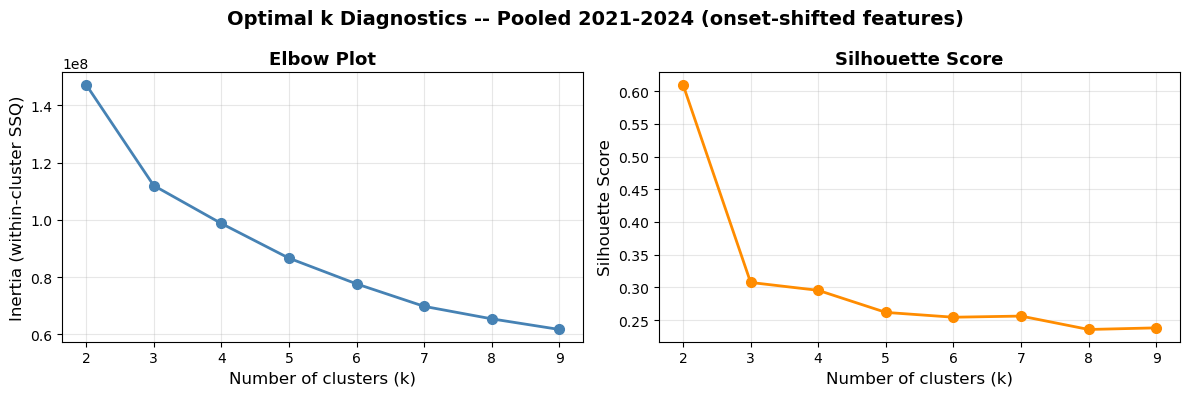


>> Review the plots and update K_FINAL (currently set to 6).
   Pick the k at the elbow AND near the silhouette peak.


In [14]:
# =============================================================================
# SECTION 6: DETERMINE OPTIMAL NUMBER OF CLUSTERS (k)
# =============================================================================
# Two complementary diagnostics:
# 1. Elbow plot (inertia): total within-cluster sum of squares.
#    Look for the "elbow" where adding more clusters has diminishing returns.
# 2. Silhouette score (-1 to +1): measures how similar a pixel is to its own
#    cluster vs. the nearest other cluster. A peak indicates natural k.
#
# NOTE: Features are now onset-shifted ("days since OGI") instead of raw
# day-of-year, so this diagnostic reflects clustering on CURVE SHAPE rather
# than calendar timing.

print("\nRunning elbow + silhouette diagnostics...")
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=KMEANS_N_INIT, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)

    idx = np.random.default_rng(RANDOM_STATE).choice(len(labels), min(50_000, len(labels)), replace=False)
    sil = silhouette_score(X_scaled[idx], labels[idx])
    sil_scores.append(sil)
    print(f"  k={k}: inertia={km.inertia_:,.0f}, silhouette={sil:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
k_vals = list(K_RANGE)

ax1.plot(k_vals, inertias, "o-", color="steelblue", linewidth=2, markersize=7)
ax1.set_xlabel("Number of clusters (k)", fontsize=12)
ax1.set_ylabel("Inertia (within-cluster SSQ)", fontsize=12)
ax1.set_title("Elbow Plot", fontsize=13, fontweight="bold")
ax1.grid(True, alpha=0.3)

ax2.plot(k_vals, sil_scores, "o-", color="darkorange", linewidth=2, markersize=7)
ax2.set_xlabel("Number of clusters (k)", fontsize=12)
ax2.set_ylabel("Silhouette Score", fontsize=12)
ax2.set_title("Silhouette Score", fontsize=13, fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.suptitle("Optimal k Diagnostics -- Pooled 2021-2024 (onset-shifted features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"\n>> Review the plots and update K_FINAL (currently set to {K_FINAL}).")
print("   Pick the k at the elbow AND near the silhouette peak.")

In [14]:
K_FINAL = 7

In [15]:
# =============================================================================
# SECTION 7: FINAL K-MEANS CLASSIFICATION
# =============================================================================
print(f"\nRunning final K-Means with k={K_FINAL}...")
km_final = KMeans(
    n_clusters=K_FINAL,
    init="k-means++",
    n_init=KMEANS_N_INIT,
    random_state=RANDOM_STATE,
    verbose=0,
)
labels_pooled = km_final.fit_predict(X_scaled)
print(f"  Clustering complete. Labels: {np.unique(labels_pooled)}")


Running final K-Means with k=7...
  Clustering complete. Labels: [0 1 2 3 4 5 6]


In [16]:
# =============================================================================
# SECTION 8: MAP LABELS BACK TO SPATIAL GRIDS (PER YEAR)
# =============================================================================
label_maps = {}

for m in meta:
    site, year = m["site"], m["year"]
    start, end, shape = m["start"], m["end"], m["shape"]
    n_pix = shape[0] * shape[1]

    label_map_flat = np.full(n_pix, -1, dtype=np.int16)
    year_mask = (valid_indices >= start) & (valid_indices < end)
    local_positions = valid_indices[year_mask] - start
    year_labels = labels_pooled[year_mask]
    label_map_flat[local_positions] = year_labels

    label_maps[(site, year)] = label_map_flat.reshape(shape)

print(f"Label maps created for: {list(label_maps.keys())}")

Label maps created for: [('br', '2021'), ('br', '2022'), ('br', '2023'), ('br', '2024'), ('bw', '2021'), ('bw', '2022'), ('bw', '2023'), ('bw', '2024'), ('de', '2021'), ('de', '2022'), ('de', '2023'), ('de', '2024'), ('usm', '2021'), ('usm', '2022'), ('usm', '2023'), ('usm', '2024'), ('uso', '2021'), ('uso', '2022'), ('uso', '2023'), ('uso', '2024'), ('nz', '2021'), ('nz', '2022'), ('nz', '2023'), ('nz', '2024')]


In [17]:
modal_maps = {}

for site in site_datasets.keys():
    site_years = [k for k in label_maps if k[0] == site]
    n_years_site = len(site_years)
    stack = np.stack([label_maps[k] for k in site_years], axis=0)

    modal_result = stats.mode(stack, axis=0, keepdims=False)
    m_map = modal_result.mode.squeeze().astype(np.int16)

    n_masked = (stack == -1).sum(axis=0)
    majority_threshold = n_years_site // 2
    m_map[n_masked > majority_threshold] = -1

    modal_maps[site] = m_map

print(f"Modal maps created for sites: {list(modal_maps.keys())}")

Modal maps created for sites: ['br', 'bw', 'de', 'usm', 'uso', 'nz']


In [18]:
# =============================================================================
# SECTION 9: CLASS PHENOMETRIC PROFILE SUMMARY
# =============================================================================
# For each class, compute median phenometric values across all pooled valid pixels.
# Timing columns here are in "days since OGI" (onset-relative), NOT calendar day-of-year.
# We also attach the median RAW OGI per class (from ogi_raw_clean) so we can
# re-anchor the reconstructed waveforms onto a real calendar axis later if desired.

df = pd.DataFrame(X_clean, columns=feat_names)
df["class"] = labels_pooled
df["OGI_raw"] = ogi_raw_clean  # raw calendar-day OGI, for reference / re-anchoring only

# Per-class medians and pixel counts
summary = df.groupby("class")[feat_names + ["OGI_raw"]].median()
counts = df.groupby("class").size().rename("pixel_count")
summary = summary.join(counts)
summary["pct_cover"] = (summary["pixel_count"] / len(df) * 100).round(1)

# Select the most interpretable columns to print
display_cols = [
    "pct_cover", "NumCycles", "has_cycle2",
    "EVImax", "EVIamp", "EVIarea",
    "OGMx", "OGD", "OGI_raw",
    "EVImax_2", "EVIarea_2"
]
print("\n=== Class Phenometric Profile Summary (medians, onset-shifted) ===")
print(summary[display_cols].to_string())

summary.to_csv("class_phenometric_summary.csv", index=True)


=== Class Phenometric Profile Summary (medians, onset-shifted) ===
       pct_cover  NumCycles  has_cycle2  EVImax  EVIamp  EVIarea  OGMx    OGD  OGI_raw  EVImax_2  EVIarea_2
class                                                                                                      
0           27.6        1.0         0.0  6248.0  4414.0  11418.0  53.0  100.0    105.0       0.0        0.0
1            5.8        2.0         1.0  6043.0  3563.0   6149.0  44.0   71.0     96.0    5389.0     6799.0
2           12.5        1.0         0.0  5060.0  2429.0   6904.0  27.0   59.0     67.0       0.0        0.0
3           24.6        1.0         0.0  3674.0  2040.0   7937.0  87.0  143.0     70.0       0.0        0.0
4           20.9        1.0         0.0  5659.0  3474.0  13708.0  97.0  166.0     47.0       0.0        0.0
5            5.0        2.0         1.0  6613.0  3228.0  15392.0  69.0  123.0    236.0    6255.0    12630.0
6            3.5        2.0         1.0  5337.0  3122.0   6177.0  23

/tmp/ipykernel_119356/788439938.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_colors = plt.cm.get_cmap("tab10", K_FINAL)(np.linspace(0, 1, K_FINAL))


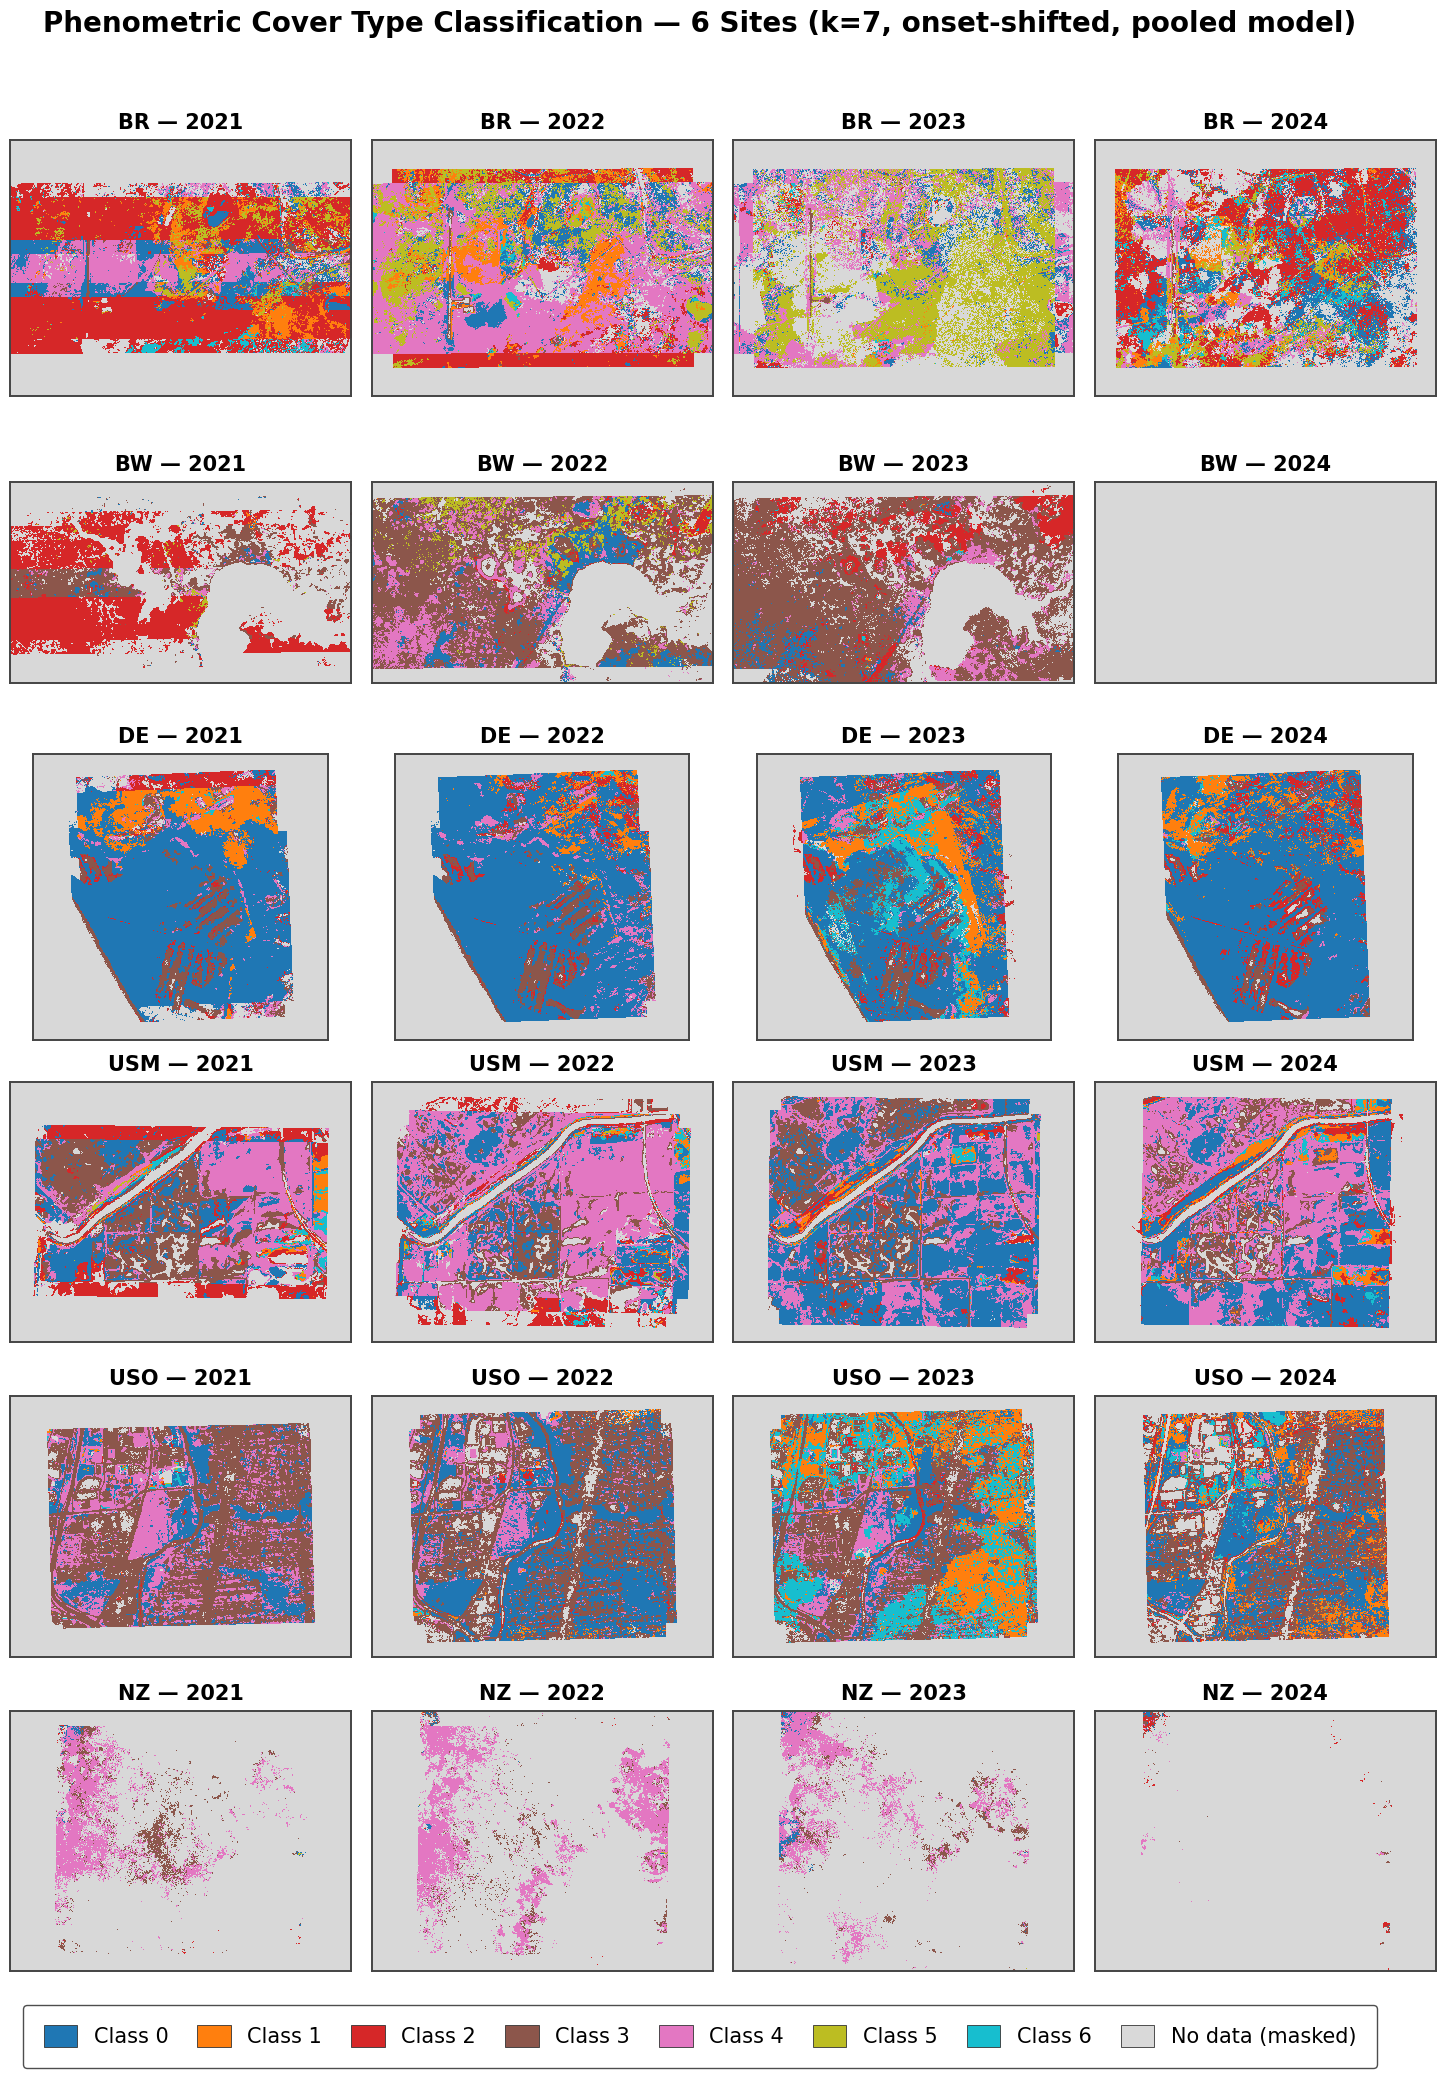

In [19]:
# =============================================================================
# VISUALIZE CLASS LABEL MAPS (PER SITE AND YEAR)
# =============================================================================

sites = list(site_datasets.keys())
n_sites = len(sites)
max_years = max(len(yd) for yd in site_datasets.values())

# --- Discrete colormap: K_FINAL classes + a dedicated "no data" gray ---
base_colors = plt.cm.get_cmap("tab10", K_FINAL)(np.linspace(0, 1, K_FINAL))
nodata_color = np.array([0.85, 0.85, 0.85, 1.0])  # light gray
all_colors = np.vstack([base_colors, nodata_color])
cmap_classes = mcolors.ListedColormap(all_colors)
bounds = np.arange(-0.5, K_FINAL + 1.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap_classes.N)

# Style
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#333333",
})

fig, axes = plt.subplots(
    n_sites, max_years,
    figsize=(4.6 * max_years, 3.5 * n_sites),
    squeeze=False,
    facecolor="white",
)

fig.subplots_adjust(wspace=0.06, hspace=0.1, top=0.93, bottom=0.045)

for row, site in enumerate(sites):
    years_for_site = list(site_datasets[site].keys())
    for col in range(max_years):
        ax = axes[row, col]
        if col < len(years_for_site):
            year = years_for_site[col]
            lmap = label_maps[(site, year)]
            # Route masked/no-data pixels (assumed NaN or -1) to the "no data" bin (K_FINAL)
            plot_arr = np.where(np.isnan(lmap) if np.issubdtype(lmap.dtype, np.floating) else (lmap < 0),
                                 K_FINAL, lmap)
            ax.imshow(plot_arr, cmap=cmap_classes, norm=norm, interpolation="nearest")
            ax.set_title(f"{site.upper()} \u2014 {year}", fontsize=15, fontweight="bold", pad=8)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.4)
                spine.set_color("#444444")
            ax.set_xticks([]); ax.set_yticks([])
        else:
            ax.axis("off")

# --- Legend ---
legend_patches = [
    Patch(facecolor=cmap_classes(i), edgecolor="#333333", linewidth=0.6, label=f"Class {i}")
    for i in range(K_FINAL)
]
legend_patches.append(
    Patch(facecolor=nodata_color, edgecolor="#333333", linewidth=0.6, label="No data (masked)")
)

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=min(K_FINAL + 1, 8),
    fontsize=15,
    frameon=True,
    framealpha=0.95,
    edgecolor="#444444",
    bbox_to_anchor=(0.5, 0.0),
    borderpad=1.0,
    handlelength=1.6,
    handleheight=1.2,
    columnspacing=1.4,
)

fig.suptitle(
    f"Phenometric Cover Type Classification \u2014 {n_sites} Sites (k={K_FINAL}, onset-shifted, pooled model)",
    fontsize=20, fontweight="bold", y=0.985,
)



#plt.savefig("phenometric_classification_clean.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

/tmp/ipykernel_119356/3319992312.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_colors = plt.cm.get_cmap("tab10", K_FINAL)(np.linspace(0, 1, K_FINAL))


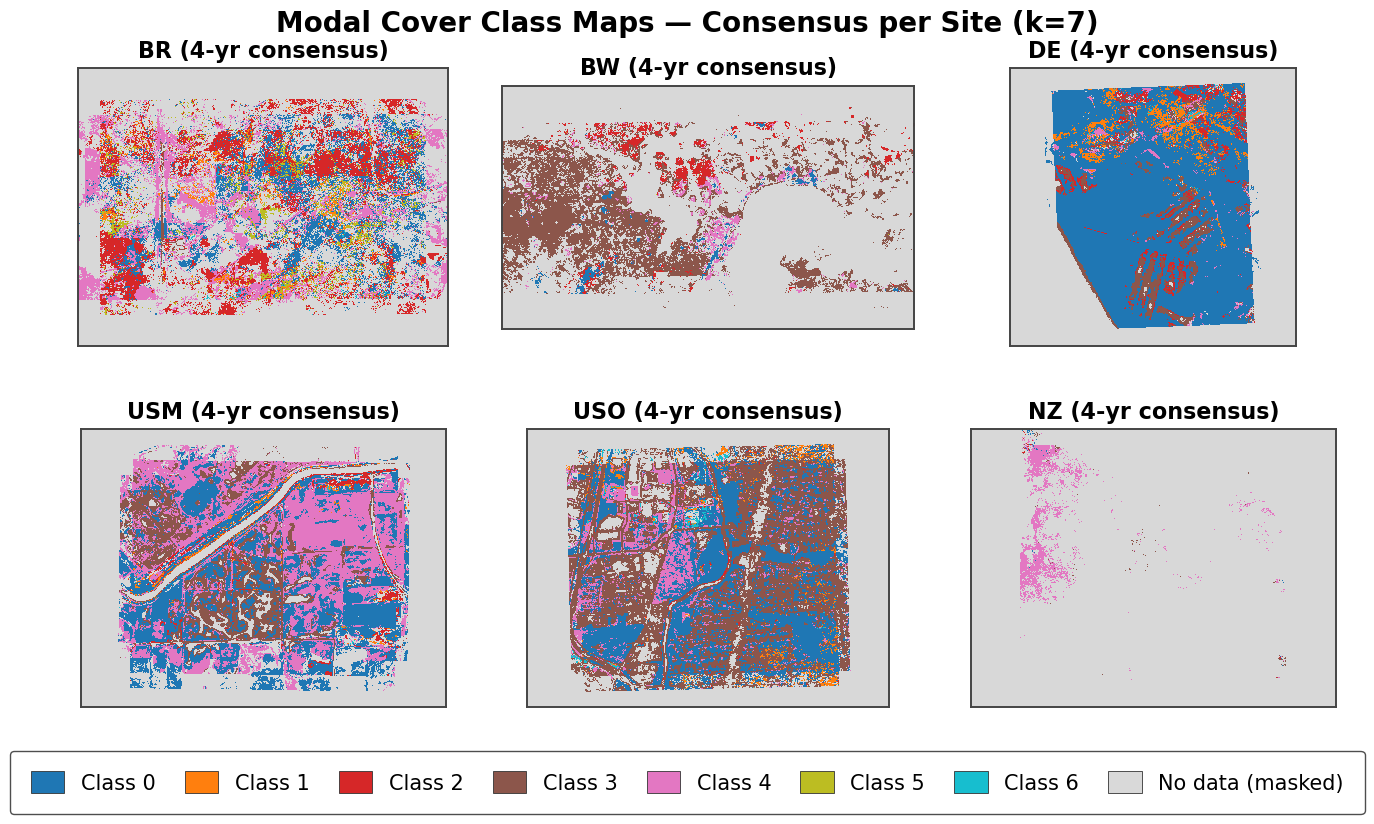

In [20]:
n_cols = min(3, n_sites)
n_rows = int(np.ceil(n_sites / n_cols))

# --- Discrete colormap: K_FINAL classes + a dedicated "no data" gray ---
base_colors = plt.cm.get_cmap("tab10", K_FINAL)(np.linspace(0, 1, K_FINAL))
nodata_color = np.array([0.85, 0.85, 0.85, 1.0])  # light gray
all_colors = np.vstack([base_colors, nodata_color])
cmap_classes = mcolors.ListedColormap(all_colors)
bounds = np.arange(-0.5, K_FINAL + 1.5, 1)
norm = mcolors.BoundaryNorm(bounds, cmap_classes.N)

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.edgecolor": "#333333",
})

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5.6 * n_cols, 4.2 * n_rows),
    squeeze=False,
    facecolor="white",
)
axes_flat = axes.ravel()

fig.subplots_adjust(wspace=0.08, hspace=0.30, top=0.90, bottom=0.14)

for i, site in enumerate(sites):
    ax = axes_flat[i]
    lmap = modal_maps[site]
    plot_arr = np.where(np.isnan(lmap) if np.issubdtype(lmap.dtype, np.floating) else (lmap < 0),
                         K_FINAL, lmap)
    ax.imshow(plot_arr, cmap=cmap_classes, norm=norm, interpolation="nearest")
    n_years_site = len(site_datasets[site])
    ax.set_title(f"{site.upper()} ({n_years_site}-yr consensus)", fontsize=16, fontweight="bold", pad=8)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.4)
        spine.set_color("#444444")
    ax.set_xticks([]); ax.set_yticks([])

for j in range(n_sites, len(axes_flat)):
    axes_flat[j].set_visible(False)

# --- Legend ---
legend_patches = [
    Patch(facecolor=cmap_classes(i), edgecolor="#333333", linewidth=0.6, label=f"Class {i}")
    for i in range(K_FINAL)
]
legend_patches.append(
    Patch(facecolor=nodata_color, edgecolor="#333333", linewidth=0.6, label="No data (masked)")
)

fig.legend(
    handles=legend_patches,
    loc="lower center",
    ncol=min(K_FINAL + 1, 8),
    fontsize=15,
    frameon=True,
    framealpha=0.95,
    edgecolor="#444444",
    bbox_to_anchor=(0.5, 0.0),
    borderpad=1.0,
    handlelength=1.6,
    handleheight=1.2,
    columnspacing=1.4,
)

fig.suptitle(
    f"Modal Cover Class Maps \u2014 Consensus per Site (k={K_FINAL})",
    fontsize=20, fontweight="bold", y=0.97,
)

# Outer frame around the whole figure
# fig.patches.extend([
#     plt.Rectangle(
#         (0.005, 0.16), 0.99, 0.80, transform=fig.transFigure,
#         fill=False, edgecolor="#222222", linewidth=1.5, zorder=1000,
#     )
# ])

#plt.savefig("modal_consensus_maps_clean.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

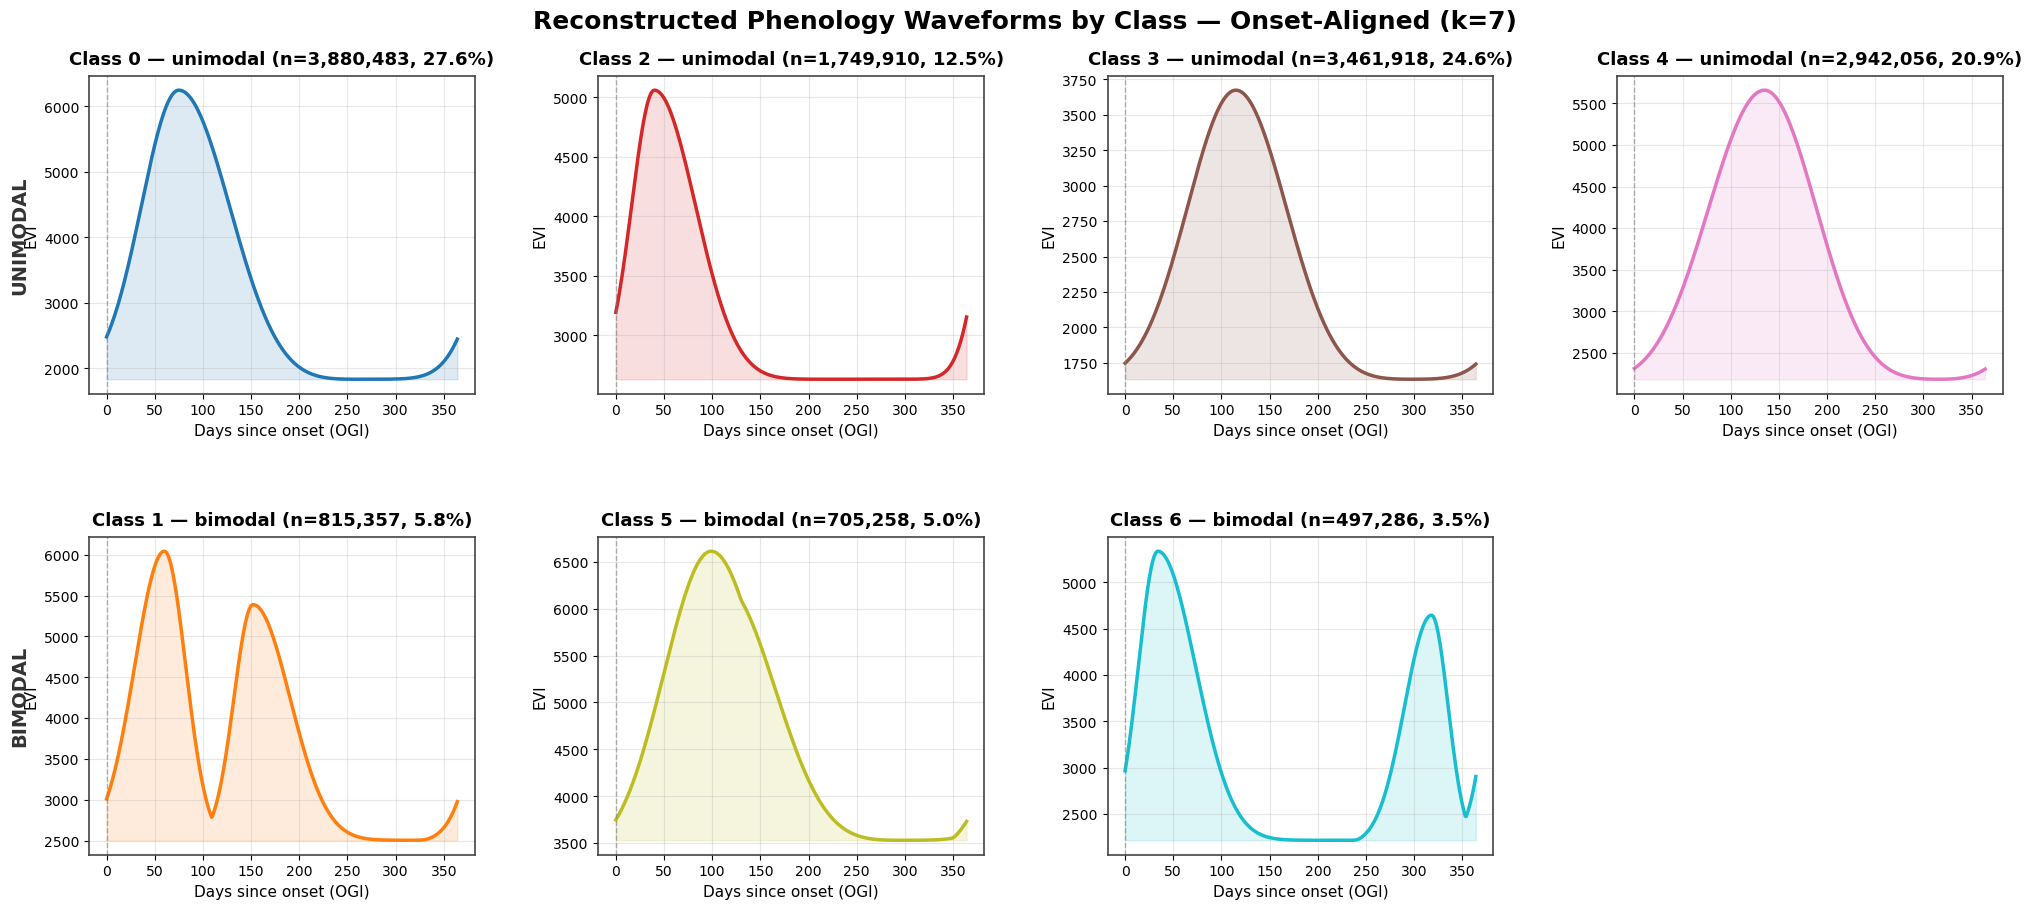

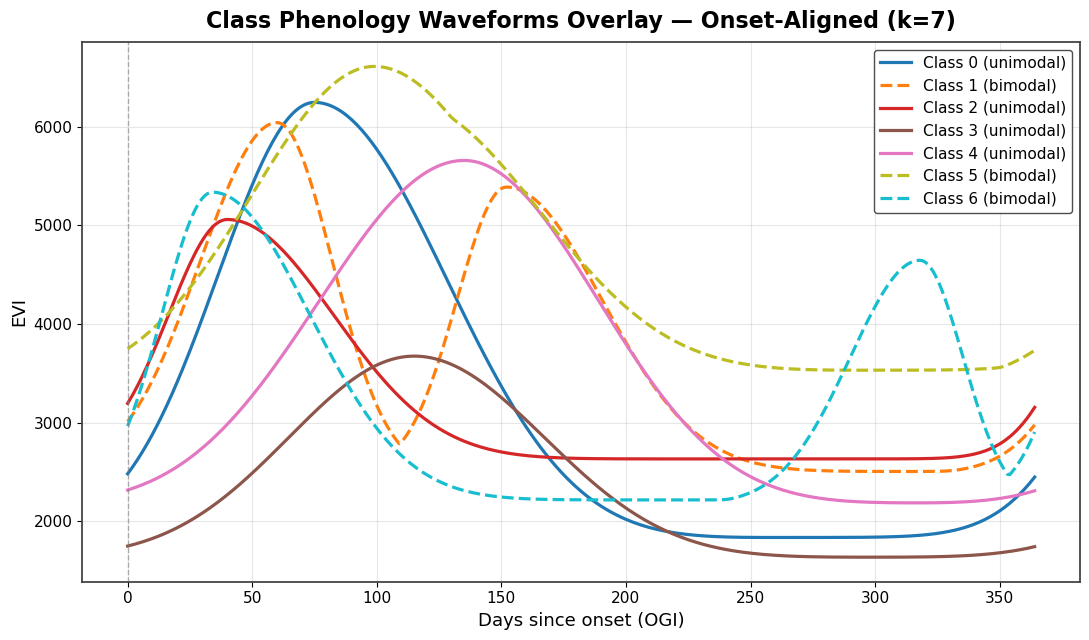

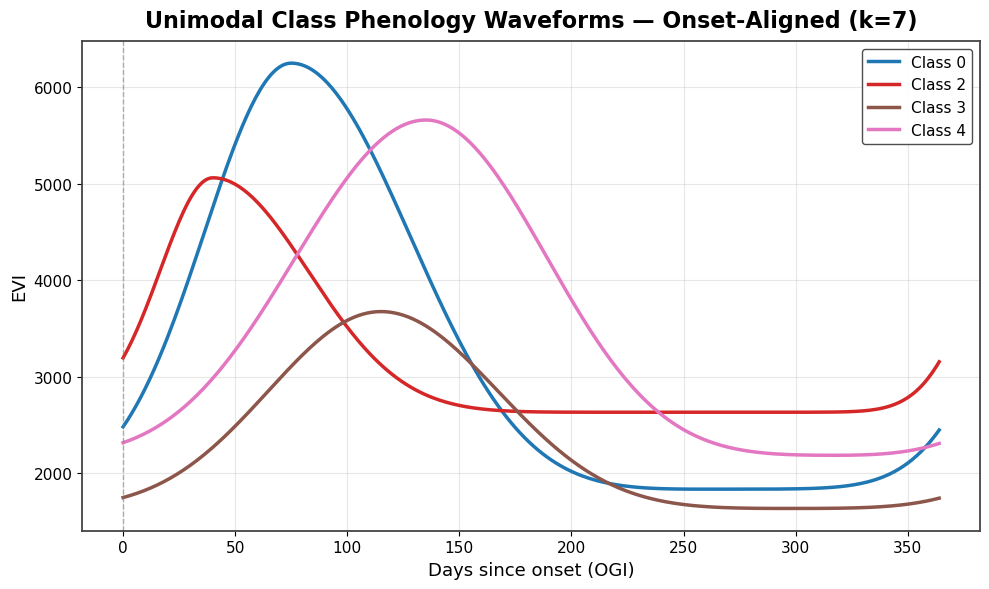

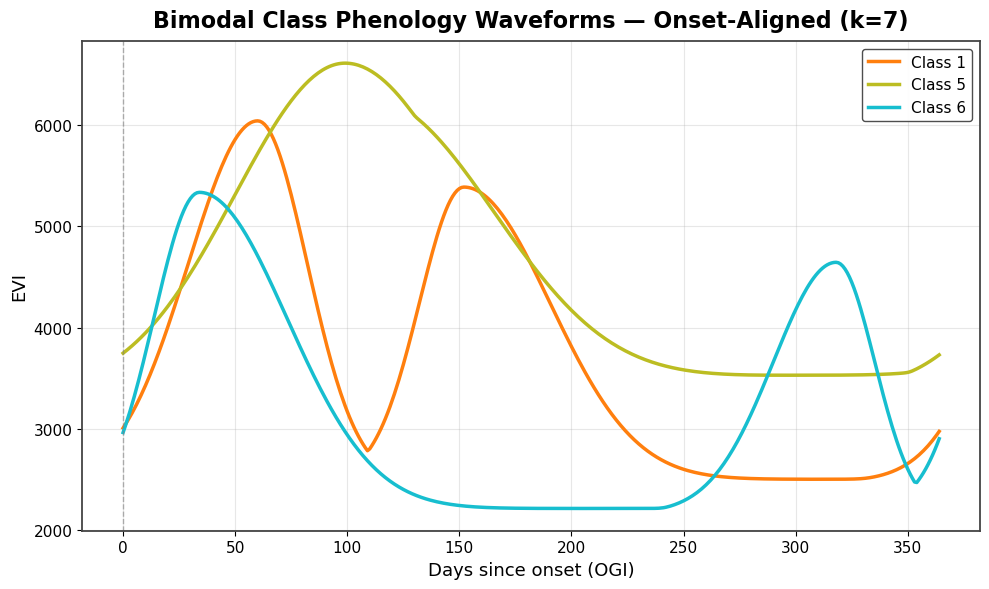

In [21]:
# =============================================================================
# RECONSTRUCT AND PLOT SYNTHETIC PHENOLOGY WAVEFORMS PER CLASS
# =============================================================================
# Reconstructs a full-cycle EVI curve for each K-Means class using only the
# onset-relative ("days since OGI") anchor points + EVImax/EVIamp from the
# class median summary.
#
# IDEA 1 UPDATE: the x-axis is now "Days since onset (OGI)" instead of
# calendar day-of-year. Since OGI is shifted to 0 for every pixel, every
# class waveform now starts its cycle at day 0 -- this is the whole point of
# the onset-alignment: it removes the calendar-date/seasonality signal and
# isolates the SHAPE of the phenology curve (duration of green-up, time to
# peak, senescence speed, etc.) for comparison across sites/years.
#
# Variables used per cycle (all already onset-shifted in the summary table):
#   0 (OGI), 50PCGI, OGMx  -> 3 known (day, fraction) points on the RISING limb
#   Peak                   -> center of the Gaussian bell
#   OGD, 50PCGD, OGMn      -> 3 known (day, fraction) points on the FALLING limb
#   EVImax, EVIamp         -> ceiling (EVImax) and floor (EVImax - EVIamp) of the curve
#
# Uses an ASYMMETRIC GAUSSIAN per limb (not double-logistic), because EVI
# seasonal curves are smooth bells around the peak, not flat-shouldered
# logistic ramps:
#   Rising limb:  0(OGI)=15%, 50PCGI=50%, OGMx=90% of amplitude gained
#   Falling limb: OGD=90% remaining, 50PCGD=50% remaining, OGMn=15% remaining
#
# PERIODIC FIX: the onset-relative axis is still circular over one cycle
# length (365 days), so distances-to-peak are computed with circular
# (wrap-around) distance instead of linear distance.
#
# Bimodal classes (has_cycle2 = 1) get a second independent bell built from
# the "_2" variables (already shifted relative to cycle-1 OGI), combined via
# elementwise smooth-max -- producing two distinct humps across the cycle.

SMOOTH_MAX_K = 0.15

def circular_distance(t, center, period=DOY_PERIOD):
    """Shortest signed distance from t to center on a circular onset-relative axis."""
    d = (t - center + period / 2) % period - period / 2
    return d

def fit_gaussian_sigma(days, fracs, center, period=DOY_PERIOD):
    """Solve sigma from f(t) = exp(-(t-center)^2 / (2*sigma^2)) using circular distance."""
    d = circular_distance(np.array(days, dtype=float), center, period)
    f = np.clip(np.array(fracs), 1e-6, 0.999999)
    sigma2 = -(d ** 2) / (2 * np.log(f))
    return np.sqrt(np.mean(sigma2))

def build_cycle_curve(t_axis, row, suffix="", period=DOY_PERIOD):
    """
    Builds one Gaussian-shaped seasonal hump using OGI(=0), 50PCGI, OGMx (rise),
    Peak (center), OGD, 50PCGD, OGMn (fall), EVImax/EVIamp (ceiling/floor).
    All timing values are already onset-shifted ("days since OGI").

    A raised-cosine taper forces both the rising-side and falling-side
    Gaussians to converge to exactly the base value at the antipode
    (period/2 away from peak), guaranteeing a continuous curve everywhere.
    """
    ogi = 0.0 if suffix == "" else row[f"OGI{suffix}"]  # cycle-1 OGI is always 0 after shifting
    p50gi, ogmx = row[f"50PCGI{suffix}"], row[f"OGMx{suffix}"]
    peak = row[f"Peak{suffix}"]
    ogd, p50gd, ogmn = row[f"OGD{suffix}"], row[f"50PCGD{suffix}"], row[f"OGMn{suffix}"]
    evimax, amp = row[f"EVImax{suffix}"], row[f"EVIamp{suffix}"]
    base = evimax - amp

    sigma_r = fit_gaussian_sigma([ogi, p50gi, ogmx], [0.15, 0.50, 0.90], peak, period)
    sigma_f = fit_gaussian_sigma([ogd, p50gd, ogmn], [0.90, 0.50, 0.15], peak, period)

    d = circular_distance(t_axis, peak, period)
    taper = np.cos(np.pi * d / period) ** 2

    gauss = np.where(
        d <= 0,
        np.exp(-(d ** 2) / (2 * sigma_r ** 2)),
        np.exp(-(d ** 2) / (2 * sigma_f ** 2)),
    )
    curve = base + amp * gauss * taper
    return curve, base

def smooth_max(a, b, k=SMOOTH_MAX_K):
    """Differentiable approximation of max(a, b) via log-sum-exp, avoids kinks at bimodal crossovers."""
    m = np.maximum(a, b)
    return m + np.log(np.exp((a - m) * k) + np.exp((b - m) * k)) / k

def build_class_waveform(row, axis=None, period=DOY_PERIOD):
    """
    Full-cycle synthetic EVI waveform for one class, on a "days since onset" axis.
    Unimodal classes: single tapered Gaussian bell from cycle-1 metrics.
    Bimodal classes: two tapered Gaussian bells (both anchored to cycle-1 OGI=0)
    combined via smooth_max.
    """
    if axis is None:
        axis = np.arange(0, period)

    curve1, base1 = build_cycle_curve(axis, row, suffix="", period=period)

    if row.get("has_cycle2", 0) >= 0.5:
        curve2, base2 = build_cycle_curve(axis, row, suffix="_2", period=period)
        curve = smooth_max(curve1, curve2)
    else:
        curve = curve1

    return axis, curve


# --- Build waveforms for every class using the class median summary ---
onset_axis = np.arange(0, DOY_PERIOD)  # "days since onset (OGI)"
class_waveforms = {}
for cls in summary.index:
    row = summary.loc[cls]
    _, curve = build_class_waveform(row, onset_axis)
    class_waveforms[cls] = curve


plt.rcParams.update({"font.family": "DejaVu Sans"})

# --- Split classes into unimodal / bimodal groups, preserving class order ---
unimodal_classes = [cls for cls in class_waveforms if summary.loc[cls, "has_cycle2"] < 0.5]
bimodal_classes = [cls for cls in class_waveforms if summary.loc[cls, "has_cycle2"] >= 0.5]

class_colors = {cls: cmap_classes(i / K_FINAL) for i, cls in enumerate(class_waveforms)}


def style_axes(ax, cls):
    is_bimodal = summary.loc[cls, "has_cycle2"] >= 0.5
    tag = "bimodal" if is_bimodal else "unimodal"
    ax.set_title(
        f"Class {cls} \u2014 {tag} (n={int(summary.loc[cls, 'pixel_count']):,}, "
        f"{summary.loc[cls, 'pct_cover']}%)",
        fontsize=13, fontweight="bold", pad=8,
    )
    ax.set_xlabel("Days since onset (OGI)", fontsize=11)
    ax.set_ylabel("EVI", fontsize=11)
    ax.tick_params(labelsize=10)
    ax.grid(alpha=0.3)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.2)
        spine.set_color("#444444")


# =============================================================================
# FIGURE 1: Grid -- unimodal classes in row 1, bimodal classes in row 2
# =============================================================================
n_cols = max(len(unimodal_classes), len(bimodal_classes))
fig, axes = plt.subplots(2, n_cols, figsize=(5.2 * n_cols, 9.5), squeeze=False, facecolor="white")
fig.subplots_adjust(wspace=0.32, hspace=0.45, top=0.90, bottom=0.08, left=0.05, right=0.97)

for row_idx, group in enumerate([unimodal_classes, bimodal_classes]):
    for col_idx in range(n_cols):
        ax = axes[row_idx, col_idx]
        if col_idx < len(group):
            cls = group[col_idx]
            curve = class_waveforms[cls]
            color = class_colors[cls]
            ax.plot(onset_axis, curve, color=color, linewidth=2.5)
            ax.fill_between(onset_axis, curve.min(), curve, alpha=0.15, color=color)
            ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
            style_axes(ax, cls)
        else:
            ax.axis("off")

# Row labels on the left margin
fig.text(0.012, axes[0, 0].get_position().y0 + (axes[0, 0].get_position().height / 2),
          "UNIMODAL", va="center", ha="left", rotation=90, fontsize=14, fontweight="bold", color="#333333")
fig.text(0.012, axes[1, 0].get_position().y0 + (axes[1, 0].get_position().height / 2),
          "BIMODAL", va="center", ha="left", rotation=90, fontsize=14, fontweight="bold", color="#333333")

fig.suptitle(
    f"Reconstructed Phenology Waveforms by Class \u2014 Onset-Aligned (k={K_FINAL})",
    fontsize=18, fontweight="bold", y=0.97,
)
# fig.patches.extend([
#     plt.Rectangle((0.005, 0.02), 0.99, 0.94, transform=fig.transFigure,
#                   fill=False, edgecolor="#222222", linewidth=1.5, zorder=1000)
# ])
plt.savefig("phenology_waveforms_grid_clean.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


# =============================================================================
# FIGURE 2: Overlay -- ALL classes together (unimodal + bimodal)
# =============================================================================
fig, ax = plt.subplots(figsize=(11, 6.5), facecolor="white")
for cls in class_waveforms:
    is_bimodal = summary.loc[cls, "has_cycle2"] >= 0.5
    ls = "--" if is_bimodal else "-"
    tag = "bimodal" if is_bimodal else "unimodal"
    ax.plot(onset_axis, class_waveforms[cls], label=f"Class {cls} ({tag})",
             color=class_colors[cls], linewidth=2.3, linestyle=ls)
ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Days since onset (OGI)", fontsize=13)
ax.set_ylabel("EVI", fontsize=13)
ax.set_title(f"Class Phenology Waveforms Overlay \u2014 Onset-Aligned (k={K_FINAL})",
             fontsize=16, fontweight="bold", pad=10)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=11, framealpha=0.95, edgecolor="#444444")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("#444444")
plt.tight_layout()
plt.savefig("phenology_overlay_all_clean.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


# =============================================================================
# FIGURE 3: Overlay -- UNIMODAL classes only
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
for cls in unimodal_classes:
    ax.plot(onset_axis, class_waveforms[cls], label=f"Class {cls}",
             color=class_colors[cls], linewidth=2.5)
ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Days since onset (OGI)", fontsize=13)
ax.set_ylabel("EVI", fontsize=13)
ax.set_title(f"Unimodal Class Phenology Waveforms \u2014 Onset-Aligned (k={K_FINAL})",
             fontsize=16, fontweight="bold", pad=10)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=11, framealpha=0.95, edgecolor="#444444")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("#444444")
plt.tight_layout()
plt.savefig("phenology_overlay_unimodal_clean.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()


# =============================================================================
# FIGURE 4: Overlay -- BIMODAL classes only
# =============================================================================
fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
for cls in bimodal_classes:
    ax.plot(onset_axis, class_waveforms[cls], label=f"Class {cls}",
             color=class_colors[cls], linewidth=2.5)
ax.axvline(0, color="gray", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Days since onset (OGI)", fontsize=13)
ax.set_ylabel("EVI", fontsize=13)
ax.set_title(f"Bimodal Class Phenology Waveforms \u2014 Onset-Aligned (k={K_FINAL})",
             fontsize=16, fontweight="bold", pad=10)
ax.tick_params(labelsize=11)
ax.grid(alpha=0.3)
ax.legend(loc="upper right", fontsize=11, framealpha=0.95, edgecolor="#444444")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.3)
    spine.set_color("#444444")
plt.tight_layout()
plt.savefig("phenology_overlay_bimodal_clean.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:
#removing intermediate variables to reduce the session file size 
del site_datasets, br_21, br_22, br_23, br_24, de_21, de_22, de_23, de_24
del usm_21, usm_22, usm_23, usm_24, uso_21, uso_22, uso_23, uso_24
del bw_21, bw_22, bw_23, bw_24, nz_21, nz_22, nz_23, nz_24
del X_pooled, ogi_raw_pooled, valid_rows_mask, df
del X, ogi_raw, mask_qa1, ds  

plt.close("all")

dill.dump_session("phenology_classification_session.pkl")